In [1]:
import pickle

with open("S3.pkl", "rb") as f:
    data = pickle.load(f)

print("Type:", type(data))

if isinstance(data, dict):
    print("\nKeys:")
    for key in data.keys():
        print(key)

FileNotFoundError: [Errno 2] No such file or directory: 'S3.pkl'

In [11]:
import pickle
import numpy as np
import pandas as pd

file_path = "../data/raw/WESAD/S2/S2_E4_Data/EDA.csv"
with open(file_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print(data.keys())
print(np.unique(data['label']))

UnpicklingError: could not find MARK

In [5]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file == "EDA.csv":
            print(os.path.join(root, file))

In [6]:
import os

path = "data/raw/WESAD/S2/S2_E4_Data/EDA.csv"
print(os.path.exists(path))

False


In [9]:
import os

for root, dirs, files in os.walk("."):
    if "EDA.csv" in files:
        print(os.path.join(root, "EDA.csv"))

In [10]:
import os
print(os.getcwd())


c:\Users\abhishek\Desktop\Stress Detection Project Somya\notebooks


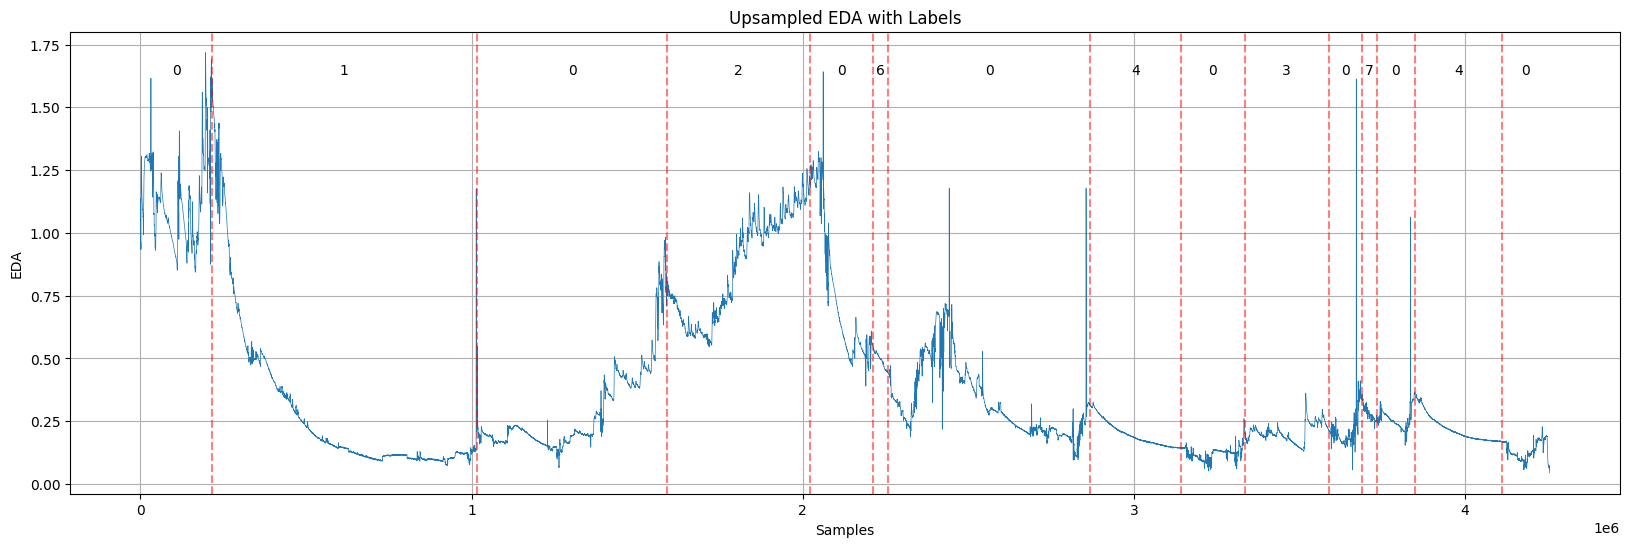

In [13]:
# upsample the EDA with labels
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Load data
with open("../data/raw/WESAD/S2/S2.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

eda = data['signal']['wrist']['EDA'].flatten()
labels = data['label']

# Upsample EDA to match label length
x_old = np.linspace(0, 1, len(eda))
x_new = np.linspace(0, 1, len(labels))

eda_up = np.interp(x_new, x_old, eda)

# Plot full signal
plt.figure(figsize=(20,6))
plt.plot(eda_up, linewidth=0.5)

# Label boundaries
changes = np.where(np.diff(labels) != 0)[0]

start = 0

for change in changes:
    middle = (start + change) // 2

    plt.text(
        middle,
        np.max(eda_up) * 0.95,
        str(int(labels[start])),   # shows 0,1,2,3...
        ha='center'
    )

    plt.axvline(change, color='red', linestyle='--', alpha=0.5)

    start = change + 1

# Last section
middle = (start + len(labels)) // 2

plt.text(
    middle,
    np.max(eda_up) * 0.95,
    str(int(labels[start])),
    ha='center'
)

plt.title("Upsampled EDA with Labels")
plt.xlabel("Samples")
plt.ylabel("EDA")
plt.grid(True)

plt.show()

NameError: name 'signal_name' is not defined

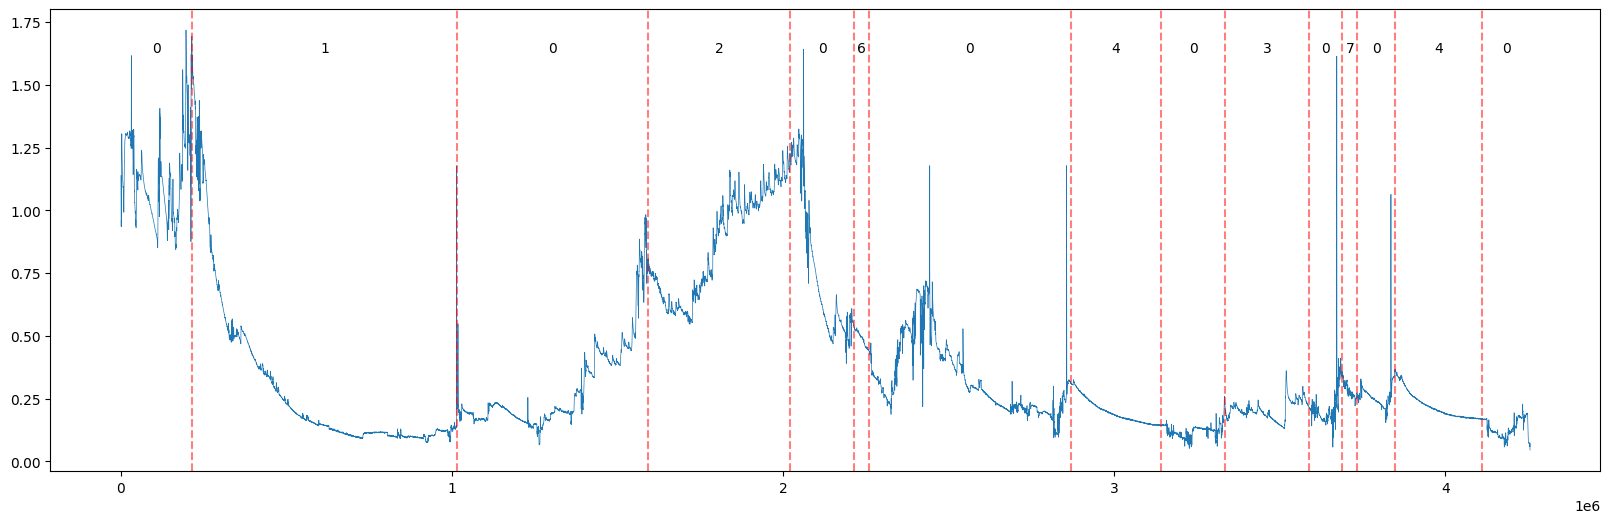

In [20]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Load data
with open("../data/raw/WESAD/S2/S2.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

labels = data['label']

def plot_signal(signal, signal_name):
    
    signal = np.array(signal).flatten()

    # Upsample signal to label length
    x_old = np.linspace(0, 1, len(signal))
    x_new = np.linspace(0, 1, len(labels))

    signal_up = np.interp(x_new, x_old, signal)

    plt.figure(figsize=(20,6))
    plt.plot(signal_up, linewidth=0.5)

    changes = np.where(np.diff(labels) != 0)[0]

    start = 0

    for change in changes:
        middle = (start + change) // 2

        plt.text(
            middle,
            np.max(signal_up) * 0.95,
            str(int(labels[start])),
            ha='center'
        )

        plt.axvline(change,
                    color='red',
                    linestyle='--',
                    alpha=0.5)

        start = change + 1

    middle = (start + len(labels)) // 2

    plt.text(
        middle,
        np.max(signal_up) * 0.95,
        str(int(labels[start])),
        ha='center'
    )
plot_signal(
    data['signal']['wrist']['EDA'],
    "Wrist EDA"
)
plt.title(signal_name)
plt.xlabel("Samples")
plt.ylabel(signal_name)
plt.grid(True)

plt.show()
print("File loaded")
print(data.keys())
    

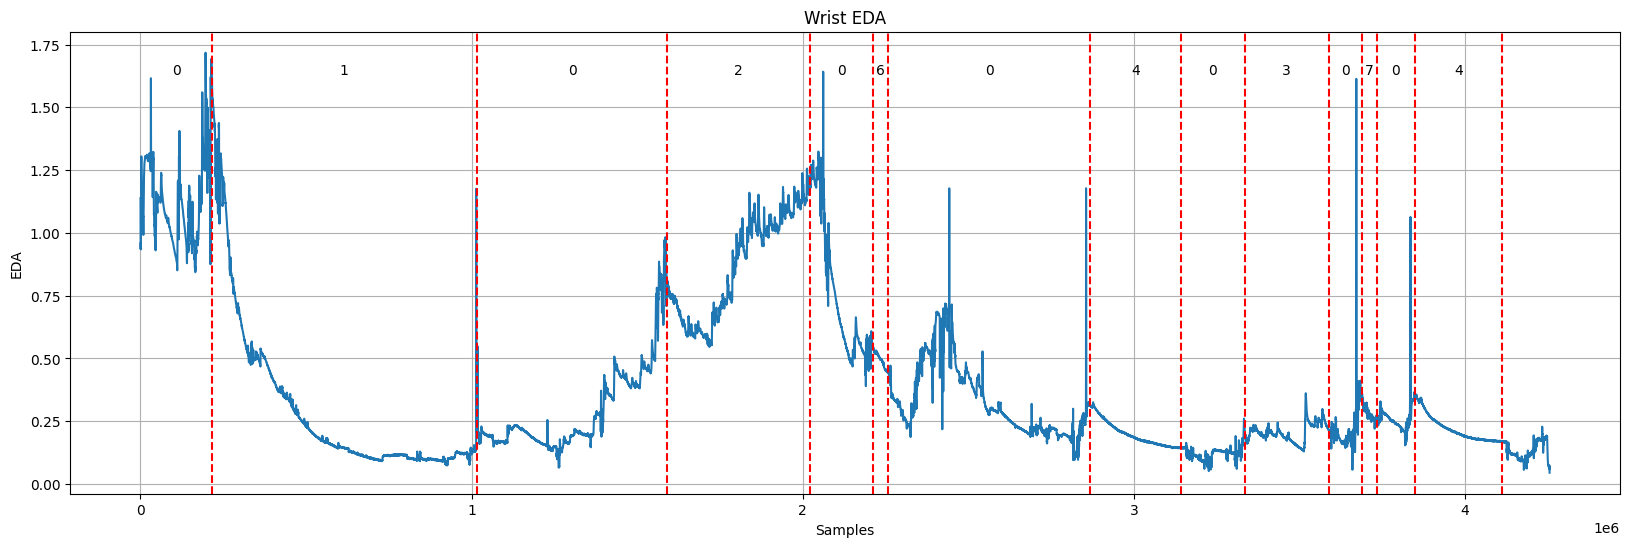

In [21]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open("../data/raw/WESAD/S2/S2.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

signal = data['signal']['wrist']['EDA'].flatten()
labels = data['label']

x_old = np.linspace(0,1,len(signal))
x_new = np.linspace(0,1,len(labels))
signal_up = np.interp(x_new,x_old,signal)

plt.figure(figsize=(20,6))
plt.plot(signal_up)

changes = np.where(np.diff(labels)!=0)[0]

start = 0
for change in changes:
    middle = (start + change)//2

    plt.text(
        middle,
        np.max(signal_up)*0.95,
        str(int(labels[start])),
        ha='center'
    )

    plt.axvline(change,color='red',linestyle='--')
    start = change+1

plt.title("Wrist EDA")
plt.xlabel("Samples")
plt.ylabel("EDA")
plt.grid(True)

plt.show()

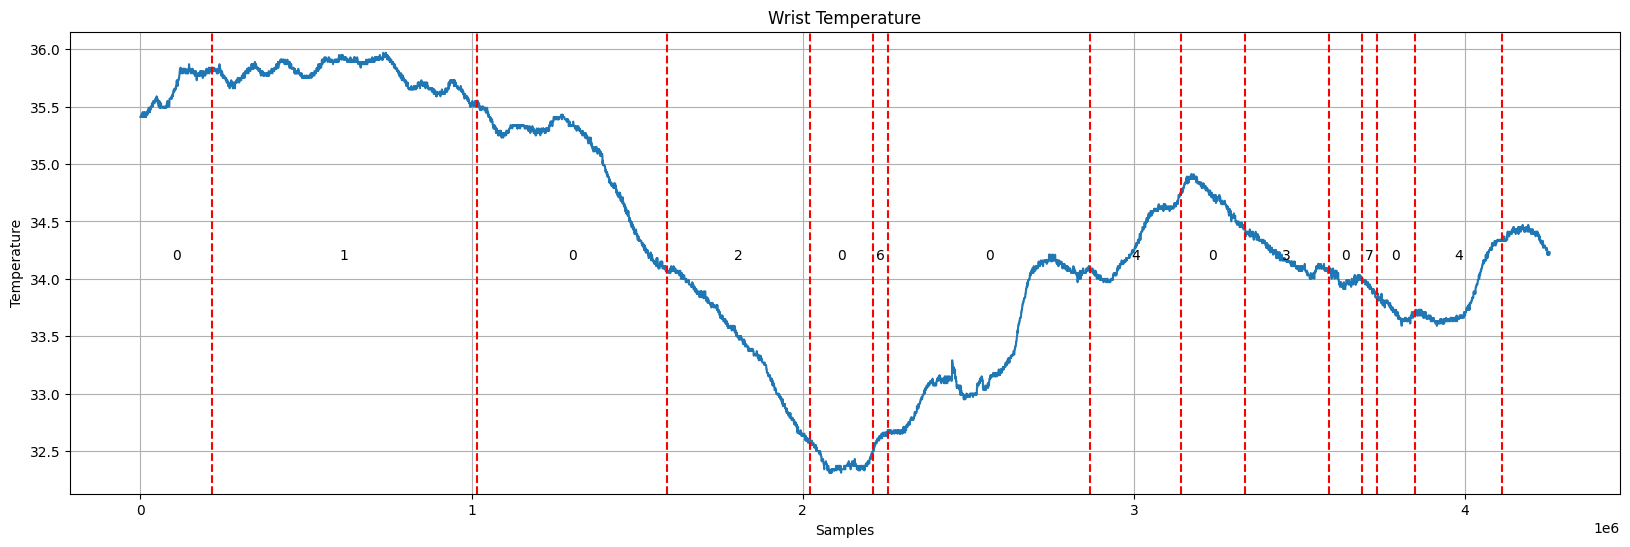

In [22]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open("../data/raw/WESAD/S2/S2.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

signal = data['signal']['wrist']['TEMP'].flatten()
labels = data['label']

x_old = np.linspace(0,1,len(signal))
x_new = np.linspace(0,1,len(labels))
signal_up = np.interp(x_new,x_old,signal)

plt.figure(figsize=(20,6))
plt.plot(signal_up)

changes = np.where(np.diff(labels)!=0)[0]

start = 0
for change in changes:
    middle = (start + change)//2

    plt.text(
        middle,
        np.max(signal_up)*0.95,
        str(int(labels[start])),
        ha='center'
    )

    plt.axvline(change,color='red',linestyle='--')
    start = change+1

plt.title("Wrist Temperature")
plt.xlabel("Samples")
plt.ylabel("Temperature")
plt.grid(True)

plt.show()

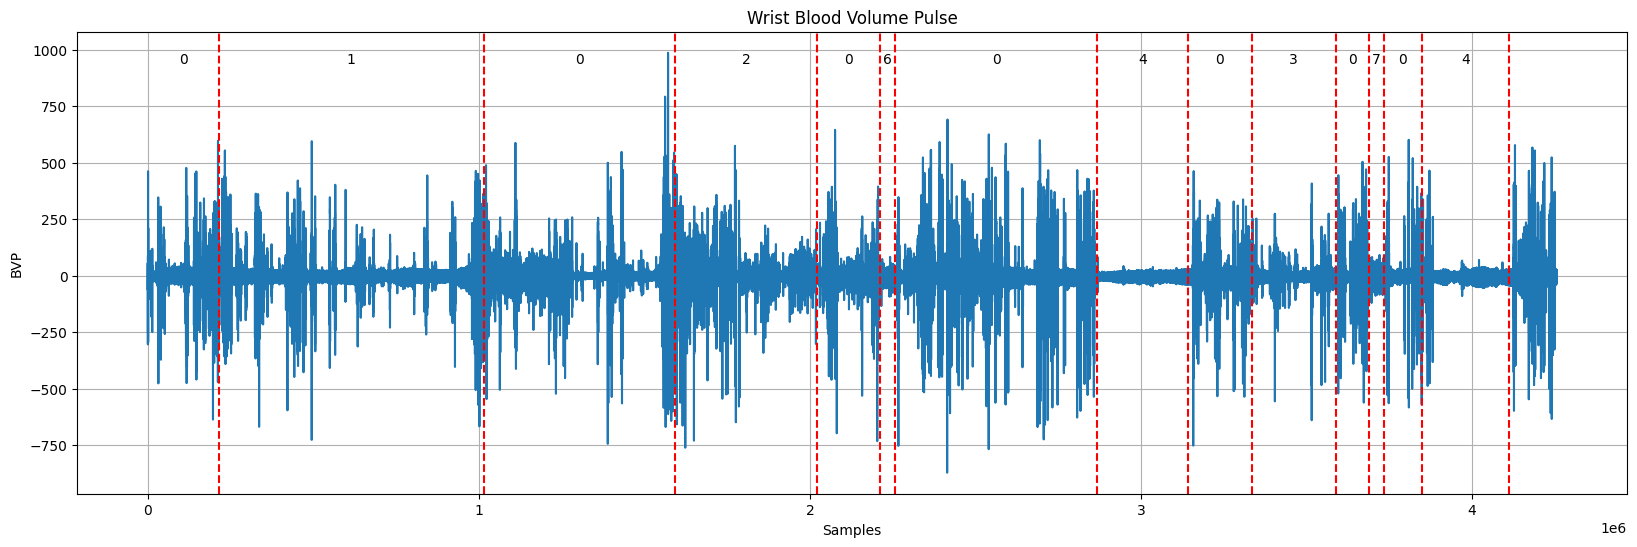

In [23]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open("../data/raw/WESAD/S2/S2.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

signal = data['signal']['wrist']['BVP'].flatten()
labels = data['label']

x_old = np.linspace(0,1,len(signal))
x_new = np.linspace(0,1,len(labels))
signal_up = np.interp(x_new,x_old,signal)

plt.figure(figsize=(20,6))
plt.plot(signal_up)

changes = np.where(np.diff(labels)!=0)[0]

start = 0
for change in changes:
    middle = (start + change)//2

    plt.text(
        middle,
        np.max(signal_up)*0.95,
        str(int(labels[start])),
        ha='center'
    )

    plt.axvline(change,color='red',linestyle='--')
    start = change+1

plt.title("Wrist Blood Volume Pulse")
plt.xlabel("Samples")
plt.ylabel("BVP")
plt.grid(True)

plt.show()

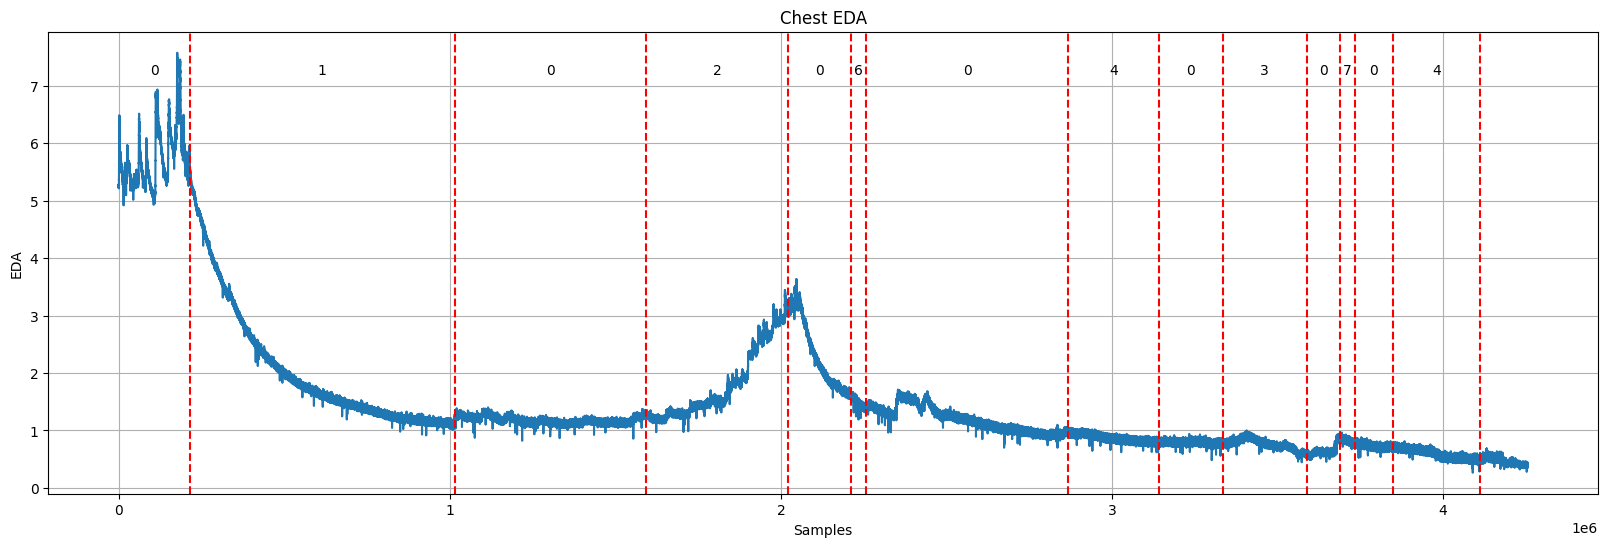

In [3]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open("../data/raw/WESAD/S2/S2.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

signal = data['signal']['chest']['EDA'].flatten()
labels = data['label']

x_old = np.linspace(0,1,len(signal))
x_new = np.linspace(0,1,len(labels))
signal_up = np.interp(x_new,x_old,signal)

plt.figure(figsize=(20,6))
plt.plot(signal_up)

changes = np.where(np.diff(labels)!=0)[0]

start = 0
for change in changes:
    middle = (start + change)//2

    plt.text(
        middle,
        np.max(signal_up)*0.95,
        str(int(labels[start])),
        ha='center'
    )

    plt.axvline(change,color='red',linestyle='--')
    start = change+1

plt.title("Chest EDA")
plt.xlabel("Samples")
plt.ylabel("EDA")
plt.grid(True)

plt.show()

In [4]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open("../data/raw/WESAD/S2/S2.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

signal = data['signal']['chest']['ECG'].flatten()
labels = data['label']

plt.figure(figsize=(20,6))
plt.plot(signal)

changes = np.where(np.diff(labels)!=0)[0]

start = 0
for change in changes:

    middle = (start + change)//2

    plt.text(
        middle,
        np.max(signal)*0.95,
        str(int(labels[start])),
        ha='center'
    )

    plt.axvline(change,color='red',linestyle='--')

    start = change+1

plt.title("Chest ECG")
plt.xlabel("Samples")
plt.ylabel("ECG")
plt.grid(True)

plt.show()

KeyboardInterrupt: 

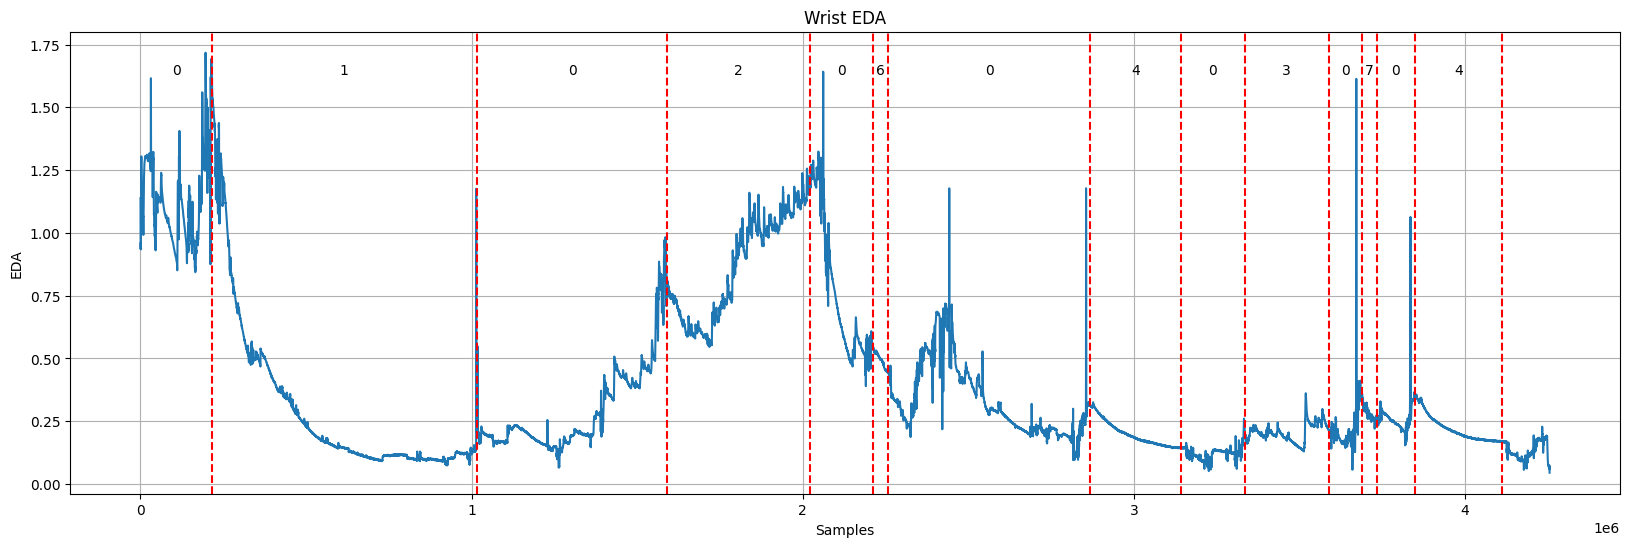

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open("../data/raw/WESAD/S2/S2.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

signal = data['signal']['wrist']['EDA'].flatten()
labels = data['label']

x_old = np.linspace(0,1,len(signal))
x_new = np.linspace(0,1,len(labels))
signal_up = np.interp(x_new,x_old,signal)

plt.figure(figsize=(20,6))
plt.plot(signal_up)

changes = np.where(np.diff(labels)!=0)[0]

start = 0
for change in changes:
    middle = (start + change)//2

    plt.text(
        middle,
        np.max(signal_up)*0.95,
        str(int(labels[start])),
        ha='center'
    )

    plt.axvline(change,color='red',linestyle='--')
    start = change+1

plt.title("Wrist EDA")
plt.xlabel("Samples")
plt.ylabel("EDA")
plt.grid(True)

plt.show()

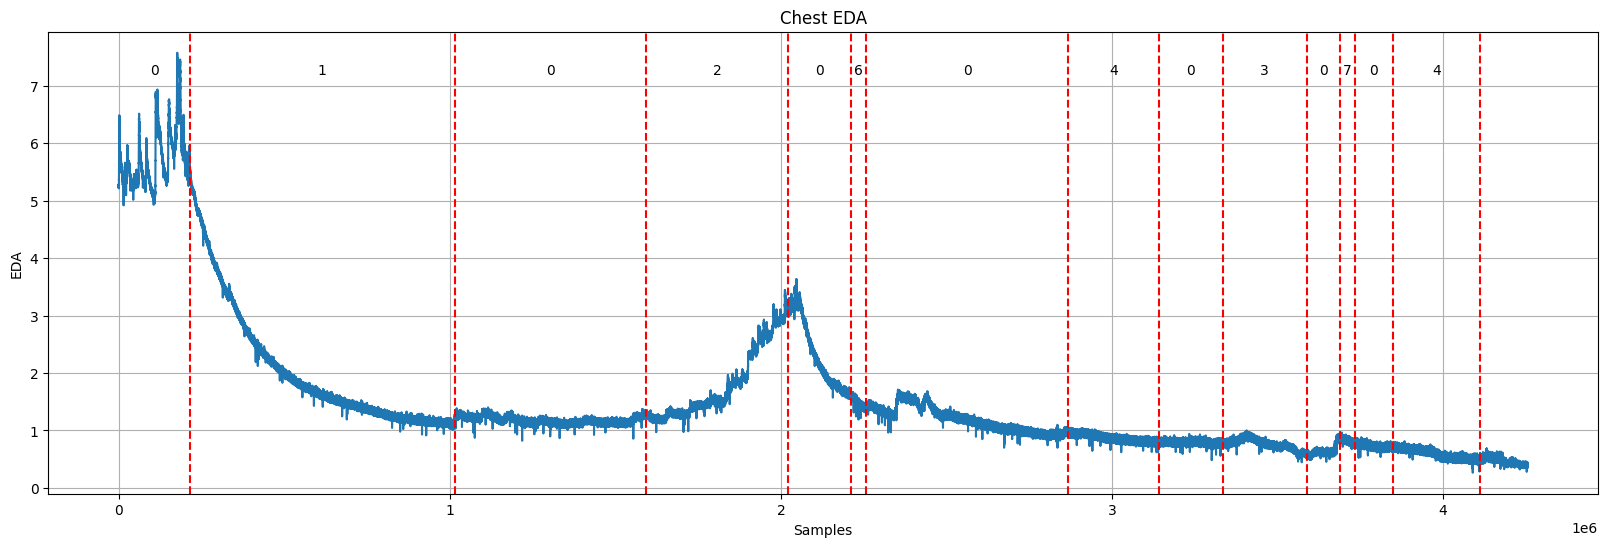

In [7]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open("../data/raw/WESAD/S2/S2.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

signal = data['signal']['chest']['EDA'].flatten()
labels = data['label']

x_old = np.linspace(0,1,len(signal))
x_new = np.linspace(0,1,len(labels))
signal_up = np.interp(x_new,x_old,signal)

plt.figure(figsize=(20,6))
plt.plot(signal_up)

changes = np.where(np.diff(labels)!=0)[0]

start = 0
for change in changes:
    middle = (start + change)//2

    plt.text(
        middle,
        np.max(signal_up)*0.95,
        str(int(labels[start])),
        ha='center'
    )

    plt.axvline(change,color='red',linestyle='--')
    start = change+1

plt.title("Chest EDA")
plt.xlabel("Samples")
plt.ylabel("EDA")
plt.grid(True)

plt.show()